This notebook documents the implementation and results of the Convolutional Photonic Reservoir Computing (CPRC) model.

This project explores a novel hybrid classical-quantum machine learning architecture designed for high-performance time-series analysis and forecasting. The model leverages the inherent physical properties of a simulated photonic quantum processor (the reservoir) to perform high-dimensional, non-linear feature mapping—acting as an advanced quantum kernel.

The core objective is to achieve demonstrable quantum advantage over conventional classical algorithms (such as LSTMs), combining the strengths of classical data handling with the superior expressivity and parallelism of quantum computing.

In [1]:
import perceval as pcvl
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import mean_squared_error

class ConvolutionalPhotonicReservoir:
    def __init__(self, kernel_size, depth=None):
        # Removed 'features_per_kernel' argument as it is auto-detected
        self.n_modes = kernel_size
        
        self.regression = Ridge(alpha=1e-5) 
        self.input_scaler = MinMaxScaler(feature_range=(0, 2*np.pi))
        
        self.depth = depth if depth is not None else kernel_size
        
        # Reservoir parameters (Fixed Random)
        rng = np.random.default_rng(seed=42)
        self.reservoir_thetas = []
        for d in range(self.depth):
            row_thetas = []
            for i in range(d % 2, self.n_modes - 1, 2):
                row_thetas.append(rng.uniform(0, 2 * np.pi))
            self.reservoir_thetas.append(row_thetas)

        # Input State
        if self.n_modes <= 8:
             self.input_state = pcvl.BasicState([1] * self.n_modes)
        else:
             state_list = [1 if i % 2 == 0 else 0 for i in range(self.n_modes)]
             self.input_state = pcvl.BasicState(state_list)
             
        # Initialize states and set n_outputs automatically
        self._init_states()

    def _init_states(self):
        """ Discover all possible quantum states to define feature space. """
        c = pcvl.Circuit(self.n_modes)
        for i in range(0, self.n_modes - 1, 2): c.add(i, pcvl.BS()) 
        for i in range(self.n_modes): c.add(i, pcvl.PS(0.1))        
        for d in range(self.depth):
             for i in range(d % 2, self.n_modes - 1, 2): c.add(i, pcvl.BS()) 
        
        p = pcvl.Processor("SLOS", self.n_modes)
        p.add(0, c)
        p.with_input(self.input_state)
        
        probs = p.probs()['results']
        
        self.all_possible_states = sorted(probs.keys(), key=lambda x: str(x))
        
        # Set n_outputs dynamically based on physics
        self.n_outputs = len(self.all_possible_states)


    def hardware_step(self, kernel_data):
        if np.isnan(kernel_data).any(): 
            return [0.0] * self.n_outputs

        circuit = pcvl.Circuit(self.n_modes)

        # 1. Pre-Mixing
        for i in range(0, self.n_modes - 1, 2):
            circuit.add(i, pcvl.BS()) 
            
        # 2. Encoding
        for i in range(self.n_modes):
            circuit.add(i, pcvl.PS(float(kernel_data[i])))
        
        # 3. Reservoir
        for d in range(self.depth):
            row_vals = self.reservoir_thetas[d]
            k = 0
            for i in range(d % 2, self.n_modes - 1, 2):
                circuit.add(i, pcvl.BS(theta=row_vals[k]))
                k += 1

        processor = pcvl.Processor("SLOS", self.n_modes)
        processor.add(0, circuit)
        processor.with_input(self.input_state)

        try:
            probs_dict = processor.probs()
            if probs_dict is not None and isinstance(probs_dict, dict) and 'results' in probs_dict:
                probs_dict = probs_dict['results']
            
            if probs_dict is None: return [0.0] * self.n_outputs

            features = [probs_dict.get(state, 0.0) for state in self.all_possible_states]
            return features

        except Exception:
            return [0.0] * self.n_outputs

    
    def convolute(self, data, stride=None):
        if stride is None: stride = self.n_modes
        features_stack = []
        for i in range(0, len(data), stride):
            window = data[i : i + self.n_modes]
            if len(window) < self.n_modes:
                window = np.pad(window, (0, self.n_modes - len(window)), "constant")
            features = self.hardware_step(window)
            features_stack.extend(features)
        return features_stack

    def transform(self, X):
        all_features = []
        for row in tqdm(X, desc="Quantum Processing"):
            f_row = self.convolute(row)
            all_features.append(f_row)
        return np.array(all_features)
    
    def fit(self, X, y, X_vali, y_vali):
        X_input_scaled = self.input_scaler.fit_transform(X)
        X_quantum = self.transform(X_input_scaled)
        self.regression.fit(X_quantum, y)
        y_vali_pred = self.predict(X_vali)
        mse = mean_squared_error(y_vali_pred, y_vali)
        print(mse)

    def predict(self, X):
        X_input_scaled = self.input_scaler.transform(X)
        X_quantum = self.transform(X_input_scaled)
        return self.regression.predict(X_quantum)
    

    def plot_circuit(self, kernel_data):
        """Costruisce e ritorna il circuito fotonico dato un kernel."""
        circuit = pcvl.Circuit(self.n_modes)

        # 1. Pre-mixing
        for i in range(0, self.n_modes - 1, 2):
            circuit.add(i, pcvl.BS())

        # 2. Encoding dei dati
        for i in range(self.n_modes):
            circuit.add(i, pcvl.PS(float(kernel_data[i])))

        # 3. Reservoir (stessa logica di hardware_step)
        for d in range(self.depth):
            row_vals = self.reservoir_thetas[d]
            k = 0
            for i in range(d % 2, self.n_modes - 1, 2):
                circuit.add(i, pcvl.BS(theta=row_vals[k]))
                k += 1

        display(pcvl.pdisplay(circuit))
    

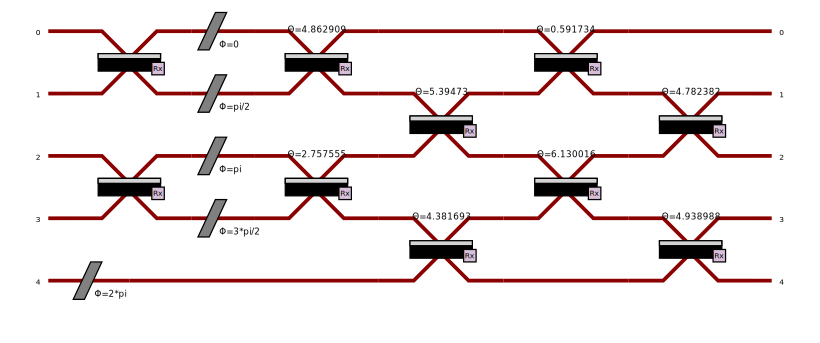

In [6]:
reservoir = ConvolutionalPhotonicReservoir(kernel_size=5, depth=4)
kernel_example = np.linspace(0, 2*np.pi, reservoir.n_modes)
reservoir.plot_circuit(kernel_example)

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_excel('train.xlsx')

all_dates = df['Date']
df = df.drop(columns=['Date'])


data_matrix = df.values


X = data_matrix[:, :-1]  
y = data_matrix[:, -1]  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_vali, y_test, y_vali = train_test_split(X_test, y_test, test_size=0.2, random_state=42)

print(f"Dimensions Train: {X_train.shape}, Test: {X_test.shape}")

KERNEL_SIZE = 5


model = ConvolutionalPhotonicReservoir(
    kernel_size=KERNEL_SIZE,
    depth=4
)

# dopo aver creato model = ConvolutionalPhotonicReservoir(...)

# prendo due righe diverse dal train
x1 = X_train[0]
x2 = X_train[1]

# faccio solo lo scaling come in fit
model.input_scaler.fit(X_train)
x1_scaled = model.input_scaler.transform(x1.reshape(1, -1))
x2_scaled = model.input_scaler.transform(x2.reshape(1, -1))

# trasformazione quantistica
f1 = model.transform(x1_scaled)[0]
f2 = model.transform(x2_scaled)[0]

print("Norm of input difference:", np.linalg.norm(x1_scaled - x2_scaled))
print("Norm of feature difference:", np.linalg.norm(f1 - f2))
print("Feature dim:", f1.shape)

print(np.linalg.norm(f1 - f2)/np.linalg.norm(f2))

Dimensions Train: (296, 223), Test: (158, 223)


Quantum Processing: 100%|██████████| 1/1 [00:00<00:00,  2.87it/s]

Norm of input difference: 20.135113502561786
Norm of feature difference: 0.22214840881959969
Feature dim: (4545,)
0.12228279431890209


In [8]:
model.fit(X_train, y_train, X_vali, y_vali)
print("Evaluating on Test set...")
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

Quantum Processing: 100%|██████████| 40/40 [00:14<00:00,  2.85it/s]


5.511117450291028e-08
Evaluating on Test set...


Quantum Processing: 100%|██████████| 158/158 [00:56<00:00,  2.79it/s]


In [9]:
print(f"MSE: {mse:.15f}")
print(f"MAE: {mae:.15f}")
print(f"R^2 SCORE:{r2:.15f}")

print("\n Comparison (Real vs Predicted):")
for real, pred in zip(y_test[:5], y_pred[:5]):
    print(f"Real: {real:.7f} | Predicted: {pred:.7f}")

MSE: 0.000000055065982
MAE: 0.000167280140360
R^2 SCORE:0.999882877623415

 Comparison (Real vs Predicted):
Real: 0.3309304 | Predicted: 0.3308544
Real: 0.4172631 | Predicted: 0.4175520
Real: 0.3940046 | Predicted: 0.3939568
Real: 0.3416318 | Predicted: 0.3416801
Real: 0.3461038 | Predicted: 0.3461212


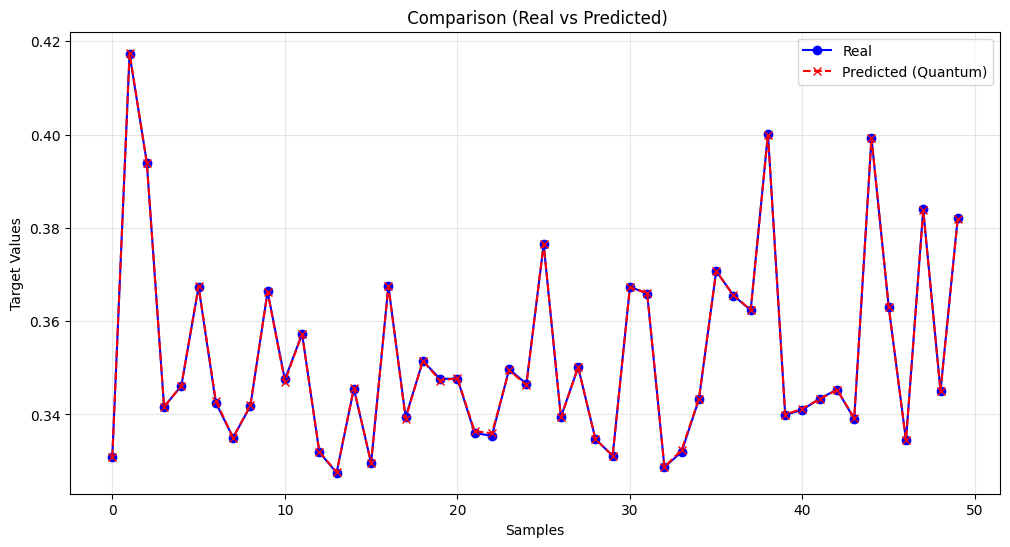

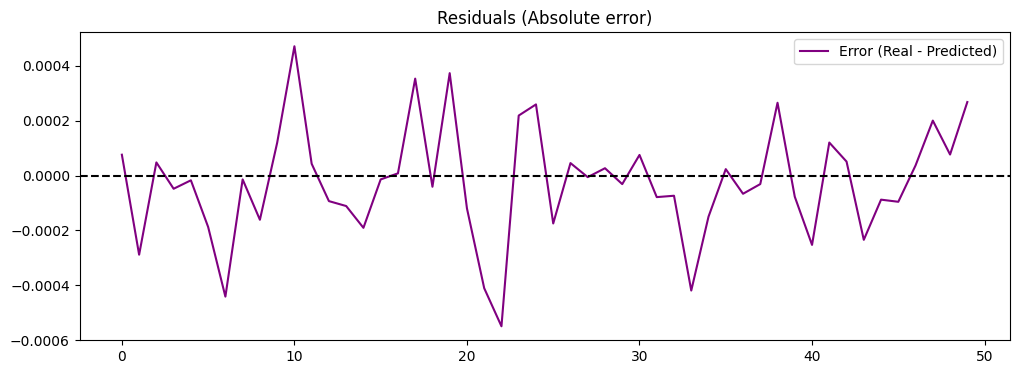

In [10]:
import matplotlib.pyplot as plt


limit = 50
plt.figure(figsize=(12, 6))

# Plot dei dati Reali
plt.plot(y_test[:limit], label='Real', color='blue', marker='o', linestyle='-')

# Plot delle Predizioni
plt.plot(y_pred[:limit], label='Predicted (Quantum)', color='red', marker='x', linestyle='--')

plt.title(f' Comparison (Real vs Predicted)')
plt.xlabel('Samples')
plt.ylabel('Target Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Zoom sull'errore
plt.figure(figsize=(12, 4))
plt.plot(y_test[:limit] - y_pred[:limit], color='purple', label='Error (Real - Predicted)')
plt.title('Residuals (Absolute error)')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()

Evaluation of the model by varying the parameters

In [11]:
kerdepth_list = []  

for j in range(1, 5): 
    
    kernel_list = []

    for i in range(2, 9):  

        data_matrix = df.values

        X = data_matrix[:, :-1]  
        y = data_matrix[:, -1]  

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"Depth={j}, Kernel={i} | Dimensions Train: {X_train.shape}, Test: {X_test.shape}")

        KERNEL_SIZE = i

        model = ConvolutionalPhotonicReservoir(
            kernel_size=KERNEL_SIZE,
            depth=j
        )

        model.fit(X_train, y_train)
        print("Evaluating on Test set...")
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # guardamos el r2 de este (depth=j, kernel=i)
        kernel_list.append(r2)

    # cuando hemos terminado todos los kernel_size para este depth j:
    kerdepth_list.append(kernel_list)

Depth=1, Kernel=2 | Dimensions Train: (395, 223), Test: (99, 223)


TypeError: ConvolutionalPhotonicReservoir.fit() missing 2 required positional arguments: 'X_vali' and 'y_vali'

In [ ]:
kernels = range(2,8)
plt.plot(kernels, kerdepth_list[3], marker='o', color = "red")

plt.xlabel('Kernel size')       # eje X
plt.ylabel(r'$R^2$')                # eje Y
plt.title(r'$R^2$ vs Kernel size (depth = 4)')

plt.grid(True,alpha = 0.3)
plt.show()

NameError: name 'kernels' is not defined

Prredicting test data

In [ ]:
test_df = pd.read_excel("test_template.xlsx")
display(test_df)

,Type,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30,Date
0,Future prediction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2051-12-24
1,Future prediction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2051-12-26
2,Future prediction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2051-12-27
3,Future prediction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2051-12-29
4,Future prediction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2051-12-30
5,Future prediction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2052-01-01
6,Missing data,0.023603,0.032985,0.035851,0.038329,0.039797,0.039475,0.039530,0.039526,0.039894,...,0.331468,0.335607,0.329724,0.333643,0.332958,0.353000,0.365298,0.343469,0.331813,2051-08-04
7,Missing data,0.023440,0.032543,0.035489,0.038116,NaN,0.039534,0.039774,0.039885,0.040341,...,0.339315,0.343687,0.337810,0.341955,0.341385,0.361487,0.374284,0.349435,0.336445,2051-09-20


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio
import io
from PIL import Image
import re

# ========= 1) Load data =========
df = pd.read_excel("train.xlsx")
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

data_cols = [c for c in df.columns if c != "Date"]
df_no_date = df[data_cols]

# ========= 2) Build multi-output dataset X_t -> Y_{t+1} =========
X_train = df_no_date.iloc[:-1].to_numpy()   # surface at time t
y_train = df_no_date.iloc[1:].to_numpy()    # surface at time t+1

print("X_train:", X_train.shape, "y_train:", y_train.shape)

# ========= 3) Fit reservoir (multi-output) =========
KERNEL_SIZE = 5
DEPTH = 4

model = ConvolutionalPhotonicReservoir(kernel_size=KERNEL_SIZE, depth=DEPTH)
model.fit(X_train, y_train)

# ========= 4) One-step-ahead predictions on the whole series =========
y_pred = model.predict(X_train)          # same shape as y_train
y_true = y_train.copy()

# DataFrames aligned on dates 1..N-1
dates_aligned = df["Date"].iloc[1:].reset_index(drop=True)

df_true = pd.DataFrame(y_true, columns=data_cols)
df_true.insert(0, "Date", dates_aligned)

df_pred = pd.DataFrame(y_pred, columns=data_cols)
df_pred.insert(0, "Date", dates_aligned)

# ========= 5) Helpers: parse tenor/maturity and build surfaces =========
def parse_surface_metadata(df):
    tenors, maturities = [], []
    mapping = {}
    for col in df.columns:
        if col == "Date":
            continue
        parts = col.split(";")
        tenor = float(parts[0].split(":")[1].strip())
        maturity = float(parts[1].split(":")[1].strip())
        tenors.append(tenor)
        maturities.append(maturity)
        mapping[col] = (tenor, maturity)
    tenors = sorted(set(tenors))
    maturities = sorted(set(maturities))
    return tenors, maturities, mapping

def reshape_to_surface(df, idx, unique_tenors, unique_maturities, mapping):
    row = df.iloc[idx]
    date = row["Date"]
    surface = np.full((len(unique_tenors), len(unique_maturities)), np.nan)
    for col, (t, m) in mapping.items():
        t_idx = unique_tenors.index(t)
        m_idx = unique_maturities.index(m)
        surface[t_idx, m_idx] = row[col]
    return surface, date

unique_tenors, unique_maturities, tm_map = parse_surface_metadata(df_true)
print("Tenors:", len(unique_tenors), "Maturities:", len(unique_maturities))

# ========= 6) Side-by-side GIF: ground truth vs prediction =========
def create_side_by_side_gif(df_true, df_pred,
                            unique_tenors, unique_maturities, mapping,
                            save_path="swaption_true_vs_pred.gif",
                            max_frames=120, fps=8):

    frames = []

    value_columns = [c for c in df_true.columns if c != "Date"]
    vmin = min(df_true[value_columns].min().min(),
               df_pred[value_columns].min().min())
    vmax = max(df_true[value_columns].max().max(),
               df_pred[value_columns].max().max())

    n = len(df_true)
    n_frames = min(n, max_frames)
    frame_indices = np.linspace(0, n-1, n_frames, dtype=int)

    for idx in frame_indices:
        surface_true, date = reshape_to_surface(df_true, idx, unique_tenors, unique_maturities, mapping)
        surface_pred, _    = reshape_to_surface(df_pred, idx, unique_tenors, unique_maturities, mapping)

        fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharex=True, sharey=True)

        im0 = axes[0].imshow(surface_true.T, cmap="RdYlGn_r",
                             aspect="equal", vmin=vmin, vmax=vmax)
        im1 = axes[1].imshow(surface_pred.T, cmap="RdYlGn_r",
                             aspect="equal", vmin=vmin, vmax=vmax)

        axes[0].set_title("Ground truth\n" + str(date.date()))
        axes[1].set_title("Predicted surface\n" + str(date.date()))

        x_ticks = range(0, len(unique_tenors), max(1, len(unique_tenors)//6))
        y_ticks = range(0, len(unique_maturities), max(1, len(unique_maturities)//6))
        axes[0].set_xticks(x_ticks)
        axes[0].set_yticks(y_ticks)
        axes[1].set_xticks(x_ticks)
        axes[1].set_yticks(y_ticks)

        axes[0].set_xticklabels([f"{unique_tenors[i]:.0f}Y" for i in x_ticks],
                                rotation=45, ha="right")
        axes[0].set_yticklabels([f"{unique_maturities[i]:.0f}Y" if unique_maturities[i]>=1
                                 else f"{int(unique_maturities[i]*12)}M"
                                 for i in y_ticks])

        axes[0].set_xlabel("Tenor")
        axes[0].set_ylabel("Maturity")
        axes[1].set_xlabel("Tenor")

        # --- colorbar moved to the far right ---
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.70])
        cbar = fig.colorbar(im1, cax=cbar_ax)
        cbar.set_label("Implied volatility")

        fig.suptitle("Swaption volatility surface – ground truth vs prediction", fontsize=11)

        buf = io.BytesIO()
        plt.tight_layout(rect=[0, 0, 0.90, 1])  # leave space for colorbar
        plt.savefig(buf, format="png", dpi=110)
        buf.seek(0)
        frames.append(Image.open(buf))
        plt.close(fig)

    imageio.mimsave(save_path, frames, fps=fps)
    print(f"GIF saved to: {save_path}")
    return save_path



X_train: (493, 224) y_train: (493, 224)


Quantum Processing: 100%|██████████| 493/493 [02:24<00:00,  3.42it/s]


Tenors: 14 Maturities: 16


In [ ]:
gif_path = create_side_by_side_gif(df_true, df_pred,
                                   unique_tenors, unique_maturities, tm_map,
                                   save_path="swaption_true_vs_pred.gif",
                                   max_frames=120, fps=8)

C:\Users\nicco\AppData\Local\Temp\ipykernel_13120\3519279068.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])  # leave space for colorbar
C:\Users\nicco\AppData\Local\Temp\ipykernel_13120\3519279068.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])  # leave space for colorbar
C:\Users\nicco\AppData\Local\Temp\ipykernel_13120\3519279068.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])  # leave space for colorbar
C:\Users\nicco\AppData\Local\Temp\ipykernel_13120\3519279068.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])  # leave space for color

GIF saved to: swaption_true_vs_pred.gif
